Répartition des classes (Déséquilibre attendu) :
higher
1    0.956757
0    0.043243
Name: proportion, dtype: float64
--------------------------------------------------

=============== Analyse Discriminante Linéaire (LDA) ===============
              precision    recall  f1-score   support

      No (0)       0.15      0.67      0.25         3
     Yes (1)       0.98      0.85      0.91        71

    accuracy                           0.84        74
   macro avg       0.57      0.76      0.58        74
weighted avg       0.95      0.84      0.88        74

ROC-AUC Score : 0.817


c:\Users\ellen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")
c:\Users\ellen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ellen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ellen\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1


=============== Analyse Discriminante Quadratique (QDA) ===============
              precision    recall  f1-score   support

      No (0)       0.00      0.00      0.00         3
     Yes (1)       0.96      1.00      0.98        71

    accuracy                           0.96        74
   macro avg       0.48      0.50      0.49        74
weighted avg       0.92      0.96      0.94        74

ROC-AUC Score : 0.500

=============== Bayésien Naïf Gaussien (GNB) ===============
              precision    recall  f1-score   support

      No (0)       0.12      0.67      0.21         3
     Yes (1)       0.98      0.80      0.88        71

    accuracy                           0.80        74
   macro avg       0.55      0.73      0.55        74
weighted avg       0.95      0.80      0.86        74

ROC-AUC Score : 0.901


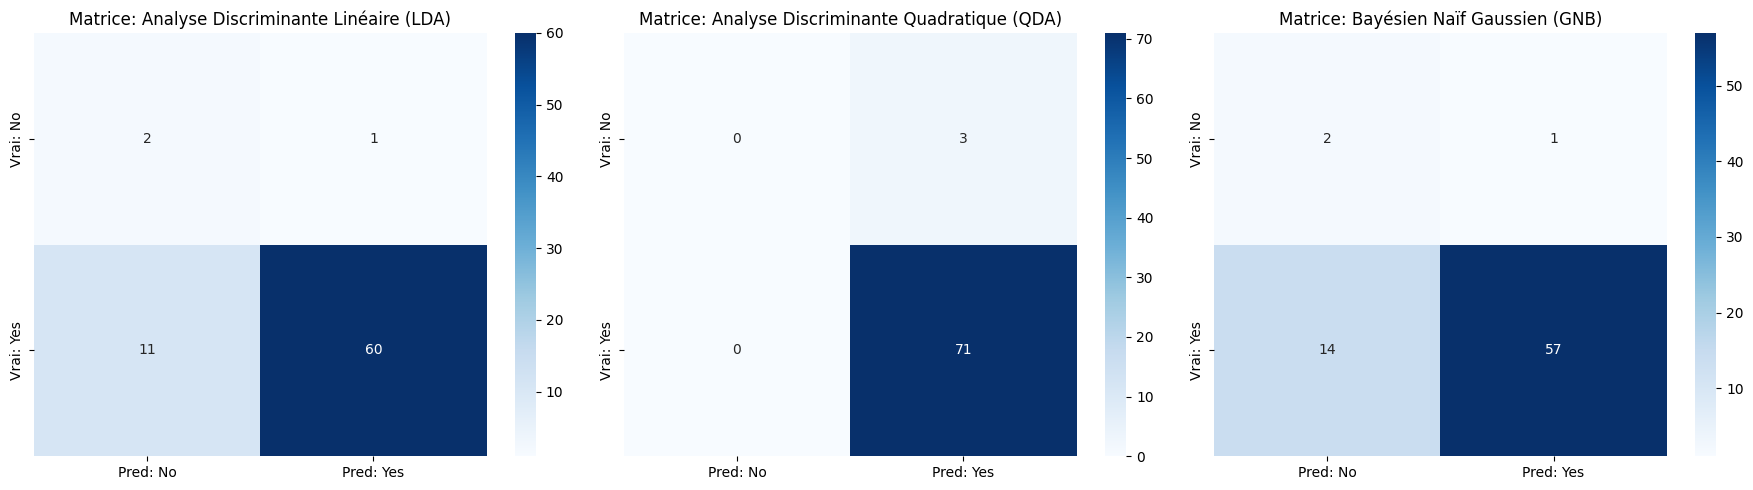

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importation des modules Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Chargement des données
# (Assurez-vous que le chemin est correct selon l'emplacement de votre notebook/script)
df = pd.read_csv("../data/merged.csv")
df = df.dropna(subset=features)

# 2. Préparation de la variable cible (Target)
# On transforme 'higher' en 1 (yes) et 0 (no)
df['higher'] = df['higher'].map({'yes': 1, 'no': 0})

print("Répartition des classes (Déséquilibre attendu) :")
print(df['higher'].value_counts(normalize=True))
print("-" * 50)

# 3. Sélection des variables explicatives (Features)
# On exclut volontairement les variables purement catégorielles textuelles (school, sex, address, etc.)
features = [
    'age', 'Medu', 'Fedu', 'traveltime', 'studytime', 
    'failures_mat', 'failures_por', 'famrel', 'freetime', 
    'goout', 'Dalc', 'Walc', 'health', 
    'absences_mat', 'absences_por', 
    'G1_mat', 'G2_mat', 'G3_mat', 
    'G1_por', 'G2_por', 'G3_por'
]

X = df[features].copy()
y = df['higher']

# 4. Transformation pour tendre vers la Normalité (Optionnel mais recommandé)
# Les absences sont souvent très asymétriques. On applique log(x + 1)
X['absences_mat'] = np.log1p(X['absences_mat'])
X['absences_por'] = np.log1p(X['absences_por'])

# 5. Séparation Train / Test
# IMPORTANT : on utilise stratify=y pour garder la même proportion de 'yes'/'no' dans le train et le test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Standardisation des données
# LDA et QDA sont sensibles à l'échelle des données.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Initialisation des Modèles
# IMPORTANT : On force priors=[0.5, 0.5] pour contrer le fait qu'il y a plus de 90% de "yes". 
# Cela force le modèle à donner autant de poids à la classe 0 qu'à la classe 1.
models = {
    "Analyse Discriminante Linéaire (LDA)": LinearDiscriminantAnalysis(priors=[0.5, 0.5]),
    "Analyse Discriminante Quadratique (QDA)": QuadraticDiscriminantAnalysis(priors=[0.5, 0.5]),
    "Bayésien Naïf Gaussien (GNB)": GaussianNB(priors=[0.5, 0.5])
}

# 8. Entraînement et Évaluation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, model) in enumerate(models.items()):
    # Entraînement
    model.fit(X_train_scaled, y_train)
    
    # Prédictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] # Probabilité de la classe 1
    
    # Affichage des métriques textuelles
    print(f"\n{'='*15} {name} {'='*15}")
    print(classification_report(y_test, y_pred, target_names=["No (0)", "Yes (1)"]))
    print(f"ROC-AUC Score : {roc_auc_score(y_test, y_prob):.3f}")
    
    # Matrice de confusion visuelle
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], 
                xticklabels=["Pred: No", "Pred: Yes"], 
                yticklabels=["Vrai: No", "Vrai: Yes"])
    axes[i].set_title(f"Matrice: {name}")

plt.tight_layout()
plt.show()

# Analyse Gemini

- Le crash de la QDA : Avec un Recall de 0.00 pour la classe 0 et un ROC-AUC de 0.500 (l'équivalent d'un tirage au sort pur), le modèle est inutilisable en l'état. Il souffre de ce qu'on appelle la malédiction de la dimensionnalité par rapport au nombre d'échantillons minoritaires.

- L'efficacité de la LDA : Malgré le déséquilibre, la LDA s'en sort bien. Elle repère 2 "No" sur les 3 présents dans le test (Recall = 0.67). Son score ROC-AUC de 0.817 montre qu'elle sépare globalement bien les deux classes. En revanche, sa précision est de 0.15 : elle génère beaucoup de faux positifs (elle a prédit "No" pour des étudiants qui ont finalement dit "Yes").

- La surprise du Bayésien Naïf (GNB) : C'est le meilleur modèle ici en termes de capacité de classement pur (ROC-AUC exceptionnel de 0.901). Tout comme la LDA, il trouve 67% des élèves en difficulté, au prix de nombreux faux positifs.

Note sur le métier : Dans un contexte scolaire, avoir une faible précision et un fort rappel sur la classe "No" n'est pas forcément mauvais. Il vaut mieux alerter à tort l'équipe pédagogique sur un élève qui va bien (faux positif) que de rater un élève qui va décrocher (faux négatif).